# 第3章 朴素贝叶斯——金融新闻情感分类

## 一、实验简介

本实验围绕 **Financial PhraseBank**（Malo et al.）数据集展开，目标是训练朴素贝叶斯（Naive Bayes）分类器，将金融新闻标题分类为 **正面（Positive）**、**负面（Negative）** 或 **中性（Neutral）**。

朴素贝叶斯是文本分类中经典且高效的基线方法。在量化交易领域，新闻情感分析被大量应用于交易信号生成。

本实验重点关注两个问题：

1. **词袋模型（CountVectorizer） vs. TF-IDF**：不同文本特征提取方式对分类效果的影响。
2. **平滑参数 α 的影响**：拉普拉斯平滑强度如何改变模型表现。

## 二、实验目标

- 理解朴素贝叶斯适用于文本分类任务的原因。
- 掌握 `CountVectorizer` 与 `TfidfVectorizer` 的基本用法与区别。
- 理解多项式朴素贝叶斯（`MultinomialNB`）的工作原理与平滑参数 α。
- 学会使用准确率、精确率、召回率、F1、混淆矩阵等指标评价多分类模型。

## 三、实验要求

- 使用同一训练/测试划分，保证对比公平。
- 比较四种方案：
  - CountVectorizer + 默认 α
  - CountVectorizer + 调优 α
  - TF-IDF + 默认 α
  - TF-IDF + 调优 α
- 输出分类报告、混淆矩阵和指标对比图。

## 四、思考提示

1. 为什么朴素贝叶斯在文本分类中表现往往不错，尽管其"特征独立"假设很强？
2. TF-IDF 相比词袋模型，在什么场景下更有优势？
3. 当某一类别样本较少时，应重点关注哪些指标？

## 1. 数据集介绍

**Financial PhraseBank** 由 Malo et al. 构建，包含约 4,840 条金融新闻语句，每条语句由多位金融领域标注者标注为 Positive、Negative 或 Neutral。

- **输入特征**：金融新闻英文语句。
- **目标变量**：情感标签（positive / negative / neutral）。

本实验使用 `sentences_allagree` 子集（所有标注者一致同意的语句），以确保标签质量最高。

> 数据来源：<https://huggingface.co/datasets/financial_phrasebank>

In [31]:
from __future__ import annotations

import re
import warnings
from time import perf_counter
import zipfile

from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")


def configure_plot_fonts() -> None:
    """配置 matplotlib 中文字体，避免 seaborn 主题覆盖字体设置。"""
    # Ref: https://matplotlib.org/stable/users/explain/text/fonts.html
    sns.set_theme(style="whitegrid")
    font_candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "PingFang SC",
        "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next(
        (name for name in font_candidates if name in available_fonts), None
    )

    if selected_font is None:
        warnings.warn(
            "未检测到常见中文字体，图表中文可能显示为方块。"
            "建议安装 'Microsoft YaHei' 或 'Noto Sans CJK SC'。",
            UserWarning,
        )
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    else:
        plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]

    plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()

DEFAULT_TEST_SIZE = 0.2
DEFAULT_RANDOM_STATE = 196823

## 2. 数据获取与读取

本实验从 Hugging Face Hub 下载 Financial PhraseBank 原始压缩包并解析 `sentences_allagree` 子集。

In [32]:
def load_financial_phrasebank(
    random_state: int = DEFAULT_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.Series]:
    """从 Hugging Face Hub 加载 Financial PhraseBank（sentences_allagree 子集）。"""
    # Ref: https://huggingface.co/datasets/financial_phrasebank
    zip_path = hf_hub_download(
        repo_id="financial_phrasebank",
        repo_type="dataset",
        filename="data/FinancialPhraseBank-v1.0.zip",
    )

    with zipfile.ZipFile(zip_path) as zf:
        raw_lines = zf.read(
            "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"
        ).decode("latin-1").splitlines()

    records: list[dict[str, str]] = []
    for line in raw_lines:
        sentence, label = line.rsplit("@", 1)
        records.append({"sentence": sentence.strip(), "label": label.strip()})

    df = pd.DataFrame(records)
    X = df["sentence"]
    y = df["label"]
    return X, y


X, y = load_financial_phrasebank()
print("样本总数：", len(X))
print("\n目标类别分布：")
print(y.value_counts())

样本总数： 2264

目标类别分布：
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


## 3. 数据概览与初步检查

我们先定量检查类别占比，尤其关注 positive 类比例。

Financial PhraseBank 是一个典型的 **类别不平衡** 数据集：neutral 类远多于 positive 和 negative。

因此，评估时需要同时关注各类别的 precision / recall / F1，而非仅看总体准确率。

In [33]:
class_counts = y.value_counts()
class_ratios = y.value_counts(normalize=True).mul(100).round(2)

positive_ratio = class_ratios.get("positive", 0.0)
positive_count = class_counts.get("positive", 0)

print("\n类别占比（%）：")
print(class_ratios)


类别占比（%）：
label
neutral     61.44
positive    25.18
negative    13.38
Name: proportion, dtype: float64


## 4. 训练集 / 测试集划分

为了保证对比公平，所有模型都使用相同的数据划分。

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=DEFAULT_TEST_SIZE,
    random_state=DEFAULT_RANDOM_STATE,
    stratify=y,
)

print("训练集大小：", len(X_train))
print("测试集大小：", len(X_test))

训练集大小： 1811
测试集大小： 453


## 5. 模型构建

本节构建并比较四个朴素贝叶斯方案。

**为什么选择 MultinomialNB？**

多项式朴素贝叶斯假设特征服从多项分布，非常适合词频 / TF-IDF 这类非负计数特征。它在文本分类任务中是最常用的朴素贝叶斯变体。

**关键参数说明：**

- `alpha`：拉普拉斯平滑参数。默认 1.0，值越大正则化越强，有助于避免零概率问题。

此外，本节用 `Pipeline` 把向量化与分类器串联起来，避免手动在训练集和测试集分别调用 `fit/transform` 时发生步骤不一致问题。

评估时我们同时记录：

- `accuracy`：整体正确率。
- `precision_macro`：先计算每个类别 precision，再做平均。
- `recall_macro`：先计算每个类别 recall，再做平均。
- `f1_macro`：各类别 F1 的宏平均，对不平衡分类更有参考价值。
- `confusion_matrix`：展示具体错分方向（例如 negative 是否常被判成 neutral）。

这个函数只负责模型结构定义：

1. 选择特征提取器（BoW 或 TF-IDF）
2. 设置平滑参数 α
3. 返回可直接 `fit/predict` 的统一管道

In [35]:
def build_nb_pipeline(
    vectorizer_type: str = "count",
    alpha: float = 1.0,
    max_features: int | None = 10000,
) -> Pipeline:
    """构建 文本向量化 + MultinomialNB 管道。"""
    if vectorizer_type == "count":
        vec = CountVectorizer(max_features=max_features, stop_words="english")
    elif vectorizer_type == "tfidf":
        vec = TfidfVectorizer(max_features=max_features, stop_words="english")
    else:
        raise ValueError(f"未知的 vectorizer_type: {vectorizer_type}")

    return Pipeline([
        ("vectorizer", vec),
        ("nb", MultinomialNB(alpha=alpha)),
    ])



这个函数只负责评估，输入训练好的模型和评估集，输出统一格式的指标字典，便于后续汇总成表格与可视化。

In [36]:
def evaluate_model(
    model: Pipeline,
    X_eval: pd.Series,
    y_eval: pd.Series,
) -> dict:
    """评估模型并返回指标字典。"""
    y_pred = model.predict(X_eval)
    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_macro": precision_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "confusion_matrix": confusion_matrix(
            y_eval, y_pred, labels=["negative", "neutral", "positive"]
        ),
        "y_pred": y_pred,
    }

### 5.1 定义四组对比实验

我们固定训练/测试划分，改变两个因素：

1. **文本特征提取方式**（CountVectorizer vs TF-IDF）
2. **平滑参数 α**（默认 1.0 vs 调优值 0.1）

四个模型的具体含义如下：

1. **BoW + α=1.0**：词袋计数 + 默认平滑，作为最基础基线。
2. **BoW + α=0.1**：词袋计数 + 较弱平滑，观察更依赖训练词频时是否提升区分能力。
3. **TF-IDF + α=1.0**：TF-IDF 加权 + 默认平滑，观察降低高频词权重后的收益。
4. **TF-IDF + α=0.1**：TF-IDF 加权 + 较弱平滑，通常是最有竞争力的组合之一。

这四组实验只改两个变量（向量化方式、α），其余配置保持一致，因此对比更公平。

In [37]:
experiments = {
    "BoW + α=1.0": build_nb_pipeline(vectorizer_type="count", alpha=1.0),
    "BoW + α=0.1": build_nb_pipeline(vectorizer_type="count", alpha=0.1),
    "TF-IDF + α=1.0": build_nb_pipeline(vectorizer_type="tfidf", alpha=1.0),
    "TF-IDF + α=0.1": build_nb_pipeline(vectorizer_type="tfidf", alpha=0.1),
}

### 5.2 逐个训练模型并记录耗时

In [38]:
fitted_models: dict[str, Pipeline] = {}
results: list[dict] = []
fit_time_rows: list[dict[str, float | str]] = []

for name, model in experiments.items():
    print(f"正在训练：{name}")
    fit_start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - fit_start
    print(f"  训练耗时：{fit_seconds:.4f}s")

    fitted_models[name] = model
    metrics = evaluate_model(model, X_test, y_test)
    metrics["model"] = name
    results.append(metrics)
    fit_time_rows.append({"model": name, "fit_seconds": fit_seconds})

正在训练：BoW + α=1.0
  训练耗时：0.0180s
正在训练：BoW + α=0.1
  训练耗时：0.0168s
正在训练：TF-IDF + α=1.0
  训练耗时：0.0171s
正在训练：TF-IDF + α=0.1
  训练耗时：0.0169s


### 5.3 汇总指标表

各指标含义：

- `accuracy`：总体预测正确比例。
- `precision_macro`：各类别 precision 的宏平均。
- `recall_macro`：各类别 recall 的宏平均。
- `f1_macro`：各类别 F1 的宏平均，适合不平衡多分类任务。
- `fit_seconds`：训练时间。

在金融情感分析场景中，通常优先关注 `f1_macro`，因为我们同样关心少数类（negative）的识别能力。

In [39]:
results_df = (
    pd.DataFrame(results)
    .set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]]
    .sort_values("f1_macro", ascending=False)
)
fit_time_df = pd.DataFrame(fit_time_rows).set_index("model")
results_with_time_df = results_df.join(fit_time_df)
best_model_name = results_df["f1_macro"].idxmax()
print(f"F1-macro 最优模型：{best_model_name}")
results_with_time_df

F1-macro 最优模型：BoW + α=0.1


,accuracy,precision_macro,recall_macro,f1_macro,fit_seconds
model,,,,,
BoW + α=0.1,0.821192,0.755269,0.762371,0.758661,0.016756
BoW + α=1.0,0.812362,0.764278,0.720189,0.729527,0.017972
TF-IDF + α=0.1,0.821192,0.788741,0.704474,0.723632,0.016944
TF-IDF + α=1.0,0.772627,0.819229,0.560200,0.528636,0.017144


## 6. 结果分析：分类报告

查看表现最好模型的详细分类报告。

阅读 `classification_report` 时建议按下面顺序：

1. 先看 **negative** 类的 recall：漏掉负面新闻在交易场景中代价更高。
2. 再看 precision：过低会产生大量误报。
3. 结合 f1-score 做平衡判断。
4. 最后看 accuracy。

In [40]:
best_model = fitted_models[best_model_name]

print(
    classification_report(
        y_test,
        best_model.predict(X_test),
        target_names=["negative", "neutral", "positive"],
        digits=4,
    )
)

              precision    recall  f1-score   support

    negative     0.6613    0.6721    0.6667        61
     neutral     0.9154    0.8957    0.9055       278
    positive     0.6891    0.7193    0.7039       114

    accuracy                         0.8212       453
   macro avg     0.7553    0.7624    0.7587       453
weighted avg     0.8243    0.8212    0.8226       453



## 7. 指标对比可视化

把四种方案的核心指标可视化。

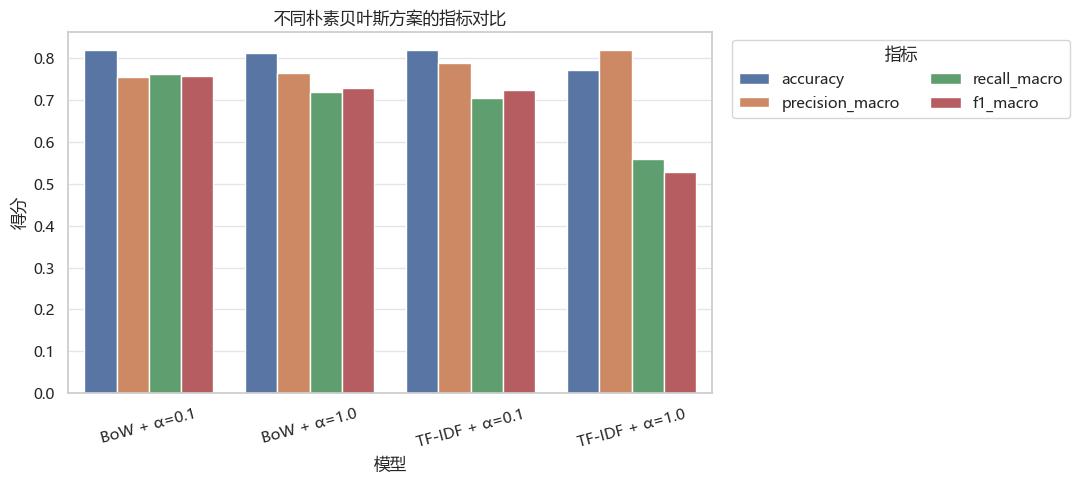

In [41]:
plot_df = results_df.reset_index().melt(
    id_vars="model", var_name="metric", value_name="value"
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=plot_df, x="model", y="value", hue="metric")
ax.set_title("不同朴素贝叶斯方案的指标对比")
ax.set_xlabel("模型")
ax.set_ylabel("得分")
plt.xticks(rotation=15)
plt.legend(title="指标", ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. 混淆矩阵对比

混淆矩阵可以帮助观察模型在三类之间的错分模式：

- 模型是否倾向于将 negative 误判为 neutral？
- positive 和 neutral 之间是否容易混淆？

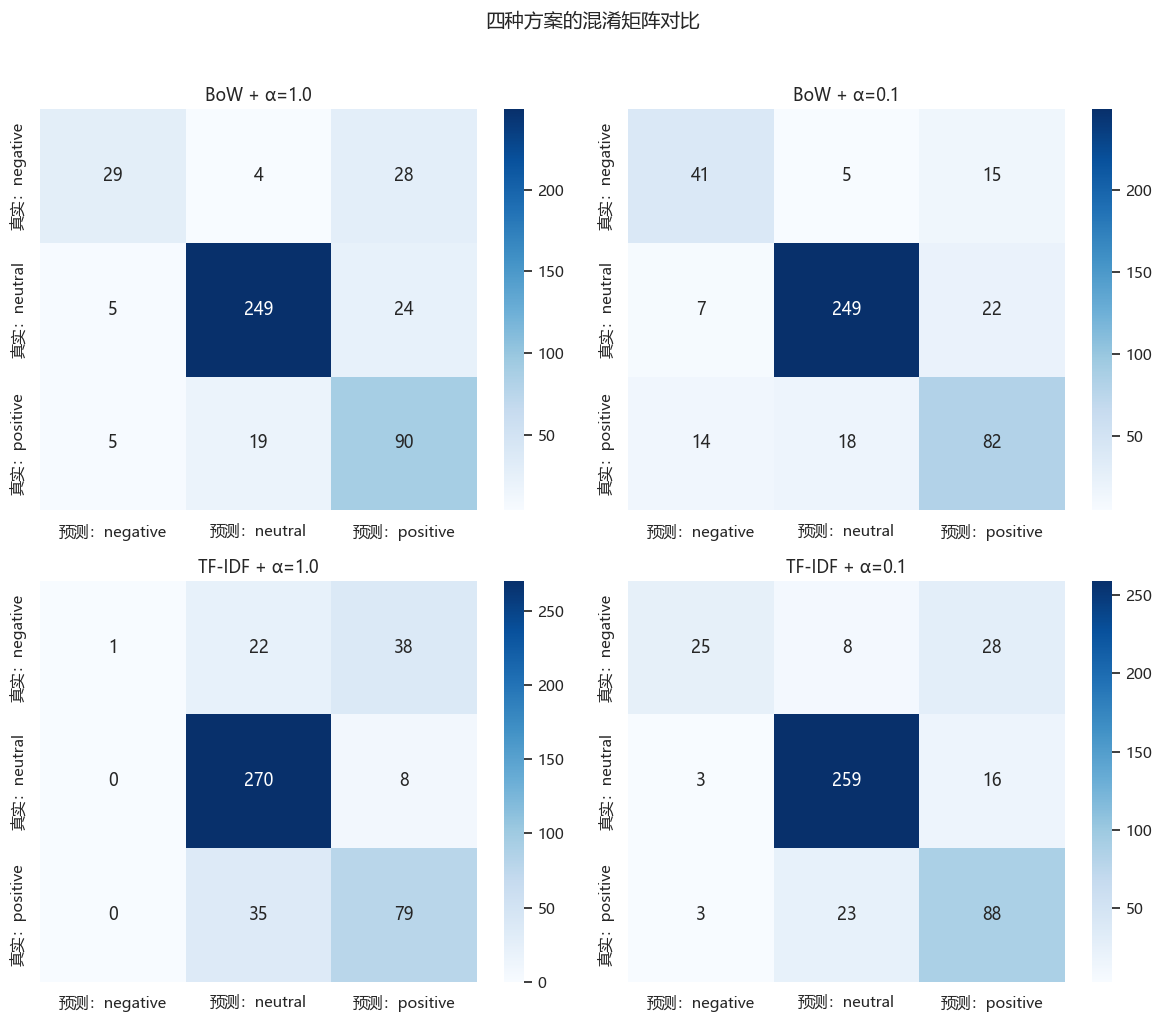

In [42]:
label_names = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, res) in zip(axes.flat, zip(experiments.keys(), results)):
    cm = res["confusion_matrix"]
    cm_df = pd.DataFrame(
        cm,
        index=[f"真实：{lb}" for lb in label_names],
        columns=[f"预测：{lb}" for lb in label_names],
    )
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)

fig.suptitle("四种方案的混淆矩阵对比", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. 特征重要性分析

朴素贝叶斯的一个优势是可解释性。我们可以查看每个类别中"最具代表性"的词语（即对数概率最高的特征）。

如果只按 `P(w|class)` 排序，一些在所有类别都高频的词可能反复出现。为了得到更有区分力的关键词，我们引入一个类似 TF-IDF 思想的"类区分分数"：

`score(w, c) = log P(w|c) - mean(log P(w|k), k != c)`

分数越高，表示该词在当前类别中概率高、在其他类别中相对低，更适合作为该类别的判别词。

另外，为了让结果更有语义解释性，这里输出 **Top-10 content words（实义词）**。

本实验使用一个轻量过滤规则近似提取实义词：

- 仅保留纯英文词（过滤数字和符号）
- 长度至少为 3
- 不在英语停用词表中

这样可以减少功能词或噪声词的干扰，让每个类别的关键词更容易解释。

In [43]:
CONTENT_WORD_PATTERN = re.compile(r"^[a-z]+$")


def is_content_word(word: str) -> bool:
    """用启发式规则过滤非实义词。"""
    return (
        len(word) >= 3
        and CONTENT_WORD_PATTERN.fullmatch(word) is not None
        and word not in ENGLISH_STOP_WORDS
    )


def show_discriminative_features(
    model: Pipeline,
    class_labels: list[str],
    n_top: int = 10,
) -> None:
    """展示每个类别中最具区分力的 Top-N 实义词。"""
    vectorizer = model.named_steps["vectorizer"]
    nb = model.named_steps["nb"]
    feature_names = np.array(vectorizer.get_feature_names_out())
    class_to_idx = {label: i for i, label in enumerate(nb.classes_)}

    for label in class_labels:
        cls_idx = class_to_idx[label]
        this_class_logp = nb.feature_log_prob_[cls_idx]
        other_class_logp = np.delete(nb.feature_log_prob_, cls_idx, axis=0).mean(axis=0)
        discriminative_scores = this_class_logp - other_class_logp
        ranked_indices = np.argsort(discriminative_scores)[::-1]

        selected_words: list[str] = []
        selected_scores: list[float] = []
        for idx in ranked_indices:
            word = feature_names[idx]
            if is_content_word(word):
                selected_words.append(word)
                selected_scores.append(float(discriminative_scores[idx]))
            if len(selected_words) == n_top:
                break

        print(f"\n类别 [{label}] 的 Top-{n_top} 区分性实义词：")
        print(
            "  "
            + ", ".join(
                f"{w} (score={s:.3f})"
                for w, s in zip(selected_words, selected_scores)
            )
        )


print(f"=== 最优模型 [{best_model_name}] 的特征词分析 ===")
show_discriminative_features(best_model, label_names)

=== 最优模型 [BoW + α=0.1] 的特征词分析 ===

类别 [negative] 的 Top-10 区分性实义词：
  decreased (score=5.843), dropped (score=5.596), slipped (score=5.398), lower (score=5.281), fell (score=5.003), fall (score=4.998), drop (score=4.998), warning (score=4.818), lost (score=4.600), widened (score=4.321)

类别 [neutral] 的 Top-10 区分性实义词：
  includes (score=4.629), rights (score=4.590), start (score=4.368), com (score=4.263), voting (score=4.263), related (score=4.207), headquartered (score=4.207), people (score=4.207), option (score=4.207), www (score=4.146)

类别 [positive] 的 Top-10 区分性实义词：
  rose (score=6.557), grew (score=5.491), increased (score=5.231), respectively (score=5.130), improved (score=4.844), narrowed (score=4.664), savings (score=4.559), positive (score=4.311), jumped (score=3.980), considerably (score=3.980)


## 10. 实验结论

请结合运行结果，完成下面的总结：

1. **TF-IDF 是否优于词袋模型？**
   - TF-IDF 通过降低高频通用词的权重、提升低频但有区分力的词的权重，通常能带来更好的分类效果。
   - 但在某些短文本场景下，词袋模型的表现可能相差不大。

2. **平滑参数 α 对结果有什么影响？**
   - α 过大会"抹平"类别之间的特征差异，降低模型区分力。
   - α 过小可能导致对训练集过拟合，尤其在词汇稀疏时。
   - 通常需要通过交叉验证选择最优 α。

3. **朴素贝叶斯为何适合文本分类？**
   - 文本特征（词频）天然高维且稀疏，朴素贝叶斯的"特征独立"假设虽然在理论上过强，但在实践中对高维稀疏数据效果出奇地好。
   - 训练速度极快，适合作为快速基线模型。

### 教学结论（参考）

在金融新闻情感分类中，**TF-IDF + 调优后的 α** 通常是最优方案。朴素贝叶斯作为基线方法，训练速度快、可解释性好，适合快速验证特征工程和数据质量。在实际量化系统中，它常作为第一阶段的快速筛选器。

## 11. 课堂思考题

1. 如果把 `max_features` 从 10000 增大到 50000 或设为 `None`（不限制），分类效果会如何变化？为什么？
2. 如果使用 n-gram（如 bigram 或 trigram）特征，模型表现是否会提升？请尝试设置 `ngram_range=(1, 2)`。
3. 尝试使用 `GridSearchCV` 搜索最优 `alpha`，与手动设定的 0.1 相比结果如何？
4. 朴素贝叶斯假设特征之间相互独立。在文本分类中，这个假设显然不成立（词语之间有共现关系）。为什么模型仍然有效？

---

### 建议运行顺序

1. 先运行所有代码单元，确保数据可以成功下载。
2. 再观察 `results_with_time_df`、混淆矩阵和特征词分析。
3. 最后根据结果撰写实验报告。